<p style="color:blue;">UNIVERSIDAD DE SAN CARLOS DE GUATEMALA</p>
<p style="color:blue;">FACULTAD DE INGENIERÍA</p>
<p style="color:blue;">INGENIERÍA EN CIENCIAS Y SISTEMAS</p>
<p style="color:blue;">SEMINARIO DE SISTEMAS 2</p>
<p style="color:blue;">SECCIÓN A</p>
<p style="color:blue;">INGRID LORENA GARCIA YANTUCHE</p>
<p style="color:blue;">CARNÉ: 201700399</p>
<p style="color:blue;">PRÁCTICA 2</p>

Instalación de las librerias necesarias a utilizar en el entorno de trabajo, se ejecuto el siguiente comando:
-  pip install pandas numpy matplotlib seaborn nltk

Posteriormente se realizo la importación de las librerías a utilizar.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re

# Carga de datos  .csv

Se realizó la carga del archivo "datos.csv" de Coursera usando la librería Pandas
- > pd.read_csv('datos.csv')

In [71]:
df = pd.read_csv('datos.csv')
total_filas = len(df)
print(f'El archivo CSV contiene {total_filas} filas.')

El archivo CSV contiene 9595 filas.


# Limpieza de datos

De los datos cargados se procedió a realizar una limpieza de datos como primer paso se realizó la eliminación de valores nulos o vacios.
- > isnull().sum()
- > dropna(inplace=True)

In [72]:
df.isnull().sum()
df.dropna(inplace=True)
print('Filas: ' ,len(df))

Filas:  3517


Eliminación de datos duplicados
- > drop_duplicates()
- > fillna(0)

In [73]:
df = df.drop_duplicates()
df = df.fillna(0)
print('Filas: ' ,len(df))

Filas:  3227


Verificar que la columna 'Rating' sea de tipo numérico
- > pd.to_numeric()

In [ ]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

Convertir la columna 'Duration' a horas: de los datos cargados se observó que la columna 'Duration' tenia este formato
- Approx. 44 hours to complete
- 2 months at 10 hours a week

Para la realización de un mejor análisis se decidió trabajar en horas 

In [76]:
def durationHoras(duration):
    duration = str(duration)
    
    if "hours" and "week" not in duration:
        hours = re.findall(r'\d+', duration)  
        if hours:
            return int(hours[0]) 
        else:
            return 0
        
    # 2 months at 10 hours a week           
    elif "months" in duration and "week" in duration:
        months_and_hours = re.findall(r'\d+', duration)
        print(months_and_hours)
        if len(months_and_hours) == 2:
            months = int(months_and_hours[0])  
            hours_per_week = int(months_and_hours[1])  
            total_weeks = months * 4 
            return total_weeks * hours_per_week 
        else:
            return 0 
    
    return 0

df['Duration'] = df['Duration'].apply(durationHoras)

df.to_csv('datos2.csv', index=False)
df[['Duration']].head()

,Duration
4,11
5,5
13,10
21,21
28,52


# Cálculo del promedio de calificaciones por curso.

Para el calculo del promedio de calificaciones por cada curso se utilizo el método:
- > df.mean()

C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3170567536.py:24: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3170567536.py:24: UserWarning: Glyph 30990 (\N{CJK UNIFIED IDEOGRAPH-790E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3170567536.py:24: UserWarning: Glyph 30693 (\N{CJK UNIFIED IDEOGRAPH-77E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3170567536.py:24: UserWarning: Glyph 35672 (\N{CJK UNIFIED IDEOGRAPH-8B58}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3170567536.py:24: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\logas\AppData\Local\Temp\ipykernel_19276\3170567536.py:24: UserWarning: Glyph 12487 (\N{KATAKANA 

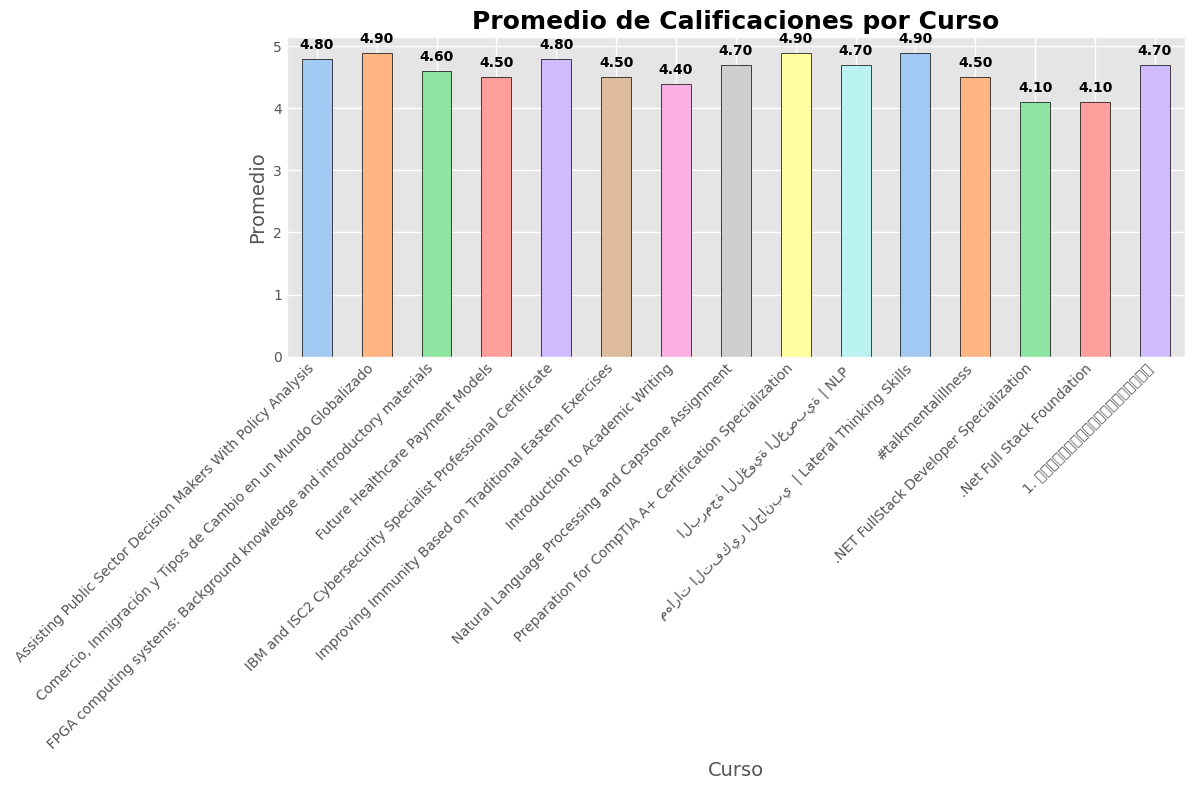

In [106]:
plt.style.use('ggplot')

promedio = df.groupby('Course Title')['Rating'].mean()

colors = sns.color_palette("pastel", 15)

plt.figure(figsize=(12, 8))

bars = promedio.head(15).plot(kind='bar', color=colors, edgecolor='black')
# Etiquetas de gráfica
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.2f}', 
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='center', 
                  xytext=(0, 10), 
                  textcoords='offset points', 
                  fontsize=10, fontweight='bold')

plt.title('Promedio de Calificaciones por Curso', fontsize=18, fontweight='bold')
plt.ylabel('Promedio', fontsize=14)
plt.xlabel('Curso', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

In [108]:
print(promedio.head(15))

Course Title
 Assisting Public Sector Decision Makers With Policy Analysis               4.8
 Comercio, Inmigración y Tipos de Cambio en un Mundo Globalizado            4.9
 FPGA computing systems: Background knowledge and introductory materials    4.6
 Future Healthcare Payment Models                                           4.5
 IBM and ISC2 Cybersecurity Specialist Professional Certificate             4.8
 Improving Immunity Based on Traditional Eastern Exercises                  4.5
 Introduction to Academic Writing                                           4.4
 Natural Language Processing and Capstone Assignment                        4.7
 Preparation for CompTIA A+ Certification Specialization                    4.9
 البرمجة اللغوية العصبية | NLP                                              4.7
 مهارات التفكير الجانبي  | Lateral Thinking Skills                          4.9
#talkmentalillness                                                          4.5
.NET FullStack Developer Sp

<p style="color:green;">De los resultados obtenidos, se puede observar que el rating de los primeros 15 cursos se encuentra entre 4.1 y 4.9. Esto indica un interés significativo en estos cursos, sugiriendo que los temas tratados son particularmente atractivos y útiles para los usuarios.</p>

#  Calcular los cursos con mayor y menor rating.

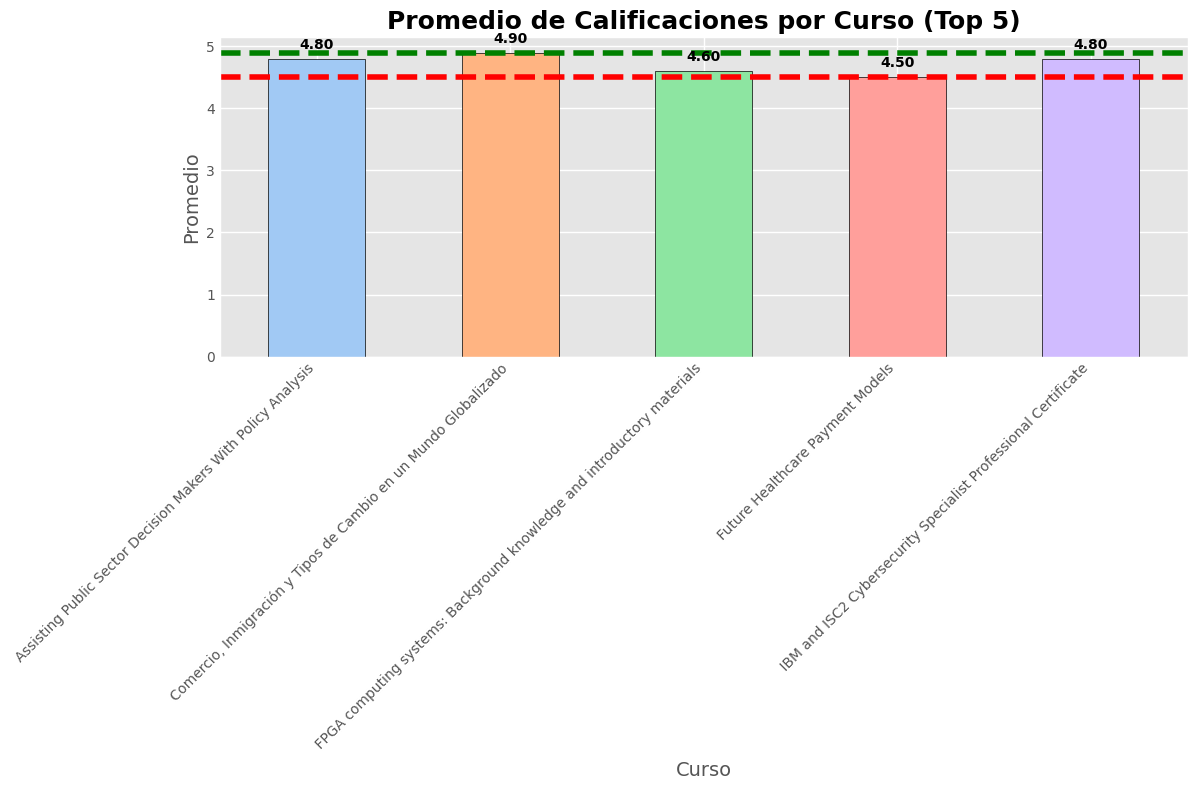

In [130]:
max_rating = df[df['Rating'] == df['Rating'].max()]
min_rating = df[df['Rating'] == df['Rating'].min()]

mayor = max_rating['Course Title'].values[0]
menor = min_rating['Course Title'].values[0]

plt.figure(figsize=(12, 8))

colors = sns.color_palette("pastel")

# Crear el gráfico de barras
bars = promedio.head(5).plot(kind='bar', color=colors, edgecolor='black')

# Resaltar el curso con la máxima calificación
if mayor in promedio.index:
    bars.patches[promedio.index.get_loc(mayor)].set_facecolor('green')
if menor in promedio.index:
    bars.patches[promedio.index.get_loc(menor)].set_facecolor('red')

# Etiquetas de gráfica
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.2f}', 
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha='center', va='bottom', 
                  xytext=(0, 5), 
                  textcoords='offset points', 
                  fontsize=10, fontweight='bold')

# Títulos y etiquetas
plt.title('Promedio de Calificaciones por Curso (Top 5)', fontsize=18, fontweight='bold')
plt.ylabel('Promedio', fontsize=14)
plt.xlabel('Curso', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)

# Leyenda
plt.axhline(y=promedio.max(), color='green', linestyle='--', label='Máxima calificación')
plt.axhline(y=promedio.min(), color='red', linestyle='--', label='Mínima calificación')

plt.tight_layout()
plt.show()


In [115]:
max_rating = df[df['Rating'] == df['Rating'].max()]
min_rating = df[df['Rating'] == df['Rating'].min()]

#print("Curso con mayor rating:", max_rating)
print("Curso con menor rating:", min_rating.head(3))

Curso con menor rating:                                            Course Title  Rating  \
1574  Software Architecture for Big Data Specialization     3.1   
2322                     Selenium WebDriver with Python     3.1   
2890  Software Architecture for Big Data Specialization     3.1   

               Level  Duration           Schedule      Review  \
1574  Advanced level        80  Flexible schedule  40 reviews   
2322  Beginner level         7  Flexible schedule  15 reviews   
2890  Advanced level        80  Flexible schedule  40 reviews   

                                    What you will learn  \
1574  Practice software engineering fundamentals; te...   
2322  Setting up the Environment for Selenium WebDri...   
2890  Practice software engineering fundamentals; te...   

                                             Skill gain  \
1574  ['Software Engineering', 'Distributed Computin...   
2322  ['Unit Testing', 'Selenium (Software)', 'Pytho...   
2890  ['Software Engineering', '